<a href="https://colab.research.google.com/github/ancestor9/Introduction-to-BigData-Analysis/blob/main/6%EC%A3%BC%EC%B0%A8/6%EC%A3%BC%EC%B0%A8_%EC%8B%A4%EC%8A%B5%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. BMI**

In [1]:
# prompt: BMI를 계산하는 코드를 만들어줘

def calculate_bmi(weight_kg, height_m):
  """
  This function calculates the Body Mass Index (BMI).

  Args:
    weight_kg: Weight in kilograms.
    height_m: Height in meters.

  Returns:
    The calculated BMI.
    Returns None if height_m is zero or negative.
  """
  if height_m <= 0:
    return None
  return weight_kg / (height_m ** 2)

# Example usage:
weight = 70  # kilograms
height = 1.75 # meters

bmi = calculate_bmi(weight, height)

if bmi is not None:
  print(f"Your BMI is: {bmi:.2f}")
else:
  print("Invalid input: Height must be a positive value.")



Your BMI is: 22.86


In [2]:
# prompt: 몸무게와 키를 입력받아 BMI를 계산 한후 BMI 상태를 나타내는 코드를 만들어줘

# Input weight and height from the user
weight_kg = float(input("몸무게를 입력하세요 (kg): "))
height_cm = float(input("키를 입력하세요 (cm): "))

# Convert height from cm to meters
height_m = height_cm / 100

# Calculate BMI using the existing function
bmi = calculate_bmi(weight_kg, height_m)

if bmi is not None:
  print(f"당신의 BMI는: {bmi:.2f}")

  # Determine BMI status
  if bmi < 18.5:
    print("BMI 상태: 저체중")
  elif 18.5 <= bmi < 25:
    print("BMI 상태: 정상")
  elif 25 <= bmi < 30:
    print("BMI 상태: 과체중")
  else:
    print("BMI 상태: 비만")
else:
  print("유효하지 않은 입력: 키는 양수 값이어야 합니다.")



몸무게를 입력하세요 (kg): 76
키를 입력하세요 (cm): 170
당신의 BMI는: 26.30
BMI 상태: 과체중


## **2. Disney Land**

In [3]:
# prompt: 디즈니랜드에서 롤로코스트를 탑승하면 요금을 계산해 주는 프로그램이다.
# 1. 15세 이하는 30 USD, 그 이상은 50 USD
# 2.  12세이하이거나 키가 120cm 미만이면 탑승금지
# 3.  탑승중 사진인하를 원하면 10 USD 요금을 추가
# 코드를 만들어줘

def calculate_disneyland_coaster_fare(age, height_cm, wants_photo):
  """
  Calculates the fare for a Disneyland roller coaster ride based on age, height, and photo option.

  Args:
    age: The age of the person.
    height_cm: The height of the person in centimeters.
    wants_photo: Boolean indicating if the person wants a photo (True) or not (False).

  Returns:
    The calculated fare in USD, or a string message if the person cannot ride.
  """
  if age < 13 or height_cm < 120:
    return "탑승 금지: 12세 이하이거나 키가 120cm 미만입니다."

  base_fare = 0
  if age < 15:
    base_fare = 30
  else:
    base_fare = 50

  total_fare = base_fare
  if wants_photo:
    total_fare += 10

  return f"탑승 요금: {total_fare} USD"

# Example usage:
age = int(input("나이를 입력하세요: "))
height = float(input("키를 입력하세요 (cm): "))
photo_option = input("사진 인화를 원하십니까? (yes/no): ").lower() == 'yes'

fare = calculate_disneyland_coaster_fare(age, height, photo_option)
fare

나이를 입력하세요: 10
키를 입력하세요 (cm): 140
사진 인화를 원하십니까? (yes/no): ㅜㅐ


'탑승 금지: 12세 이하이거나 키가 120cm 미만입니다.'

## **3. requests**

<img src='https://i.ytimg.com/vi/nGN4--jJ2fg/maxresdefault.jpg' height=300>

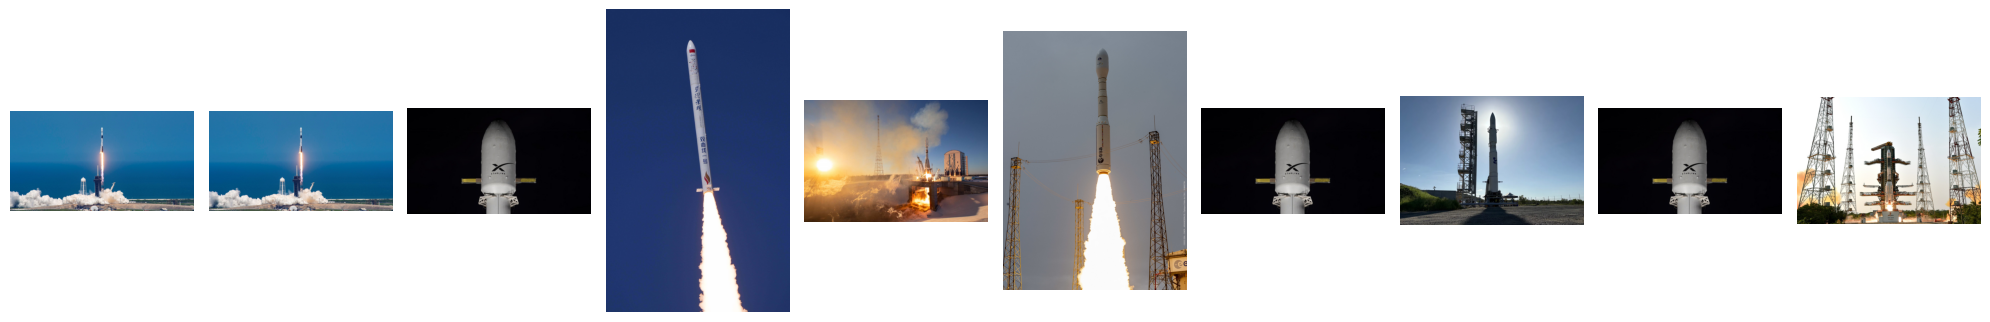

In [5]:
# prompt: https://ll.thespacedevs.com/2.0.0/launch/upcoming  이 사이트에서 발사 이미지를 10장 가져와 시각화 이미지를 해주는 코드

import requests
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

def get_launch_images(api_url, num_images=10):
    """
    Fetches launch images from the provided API URL.

    Args:
      api_url: The URL of the API endpoint.
      num_images: The number of images to fetch.

    Returns:
      A list of image URLs.
    """
    try:
        response = requests.get(api_url)
        response.raise_for_status()  # Raise an HTTPError for bad responses
        data = response.json()
        image_urls = []
        for launch in data.get('results', [])[:num_images]:
            if 'image' in launch and launch['image']:
                image_urls.append(launch['image'])
        return image_urls
    except requests.exceptions.RequestException as e:
        print(f"Error fetching data: {e}")
        return []

def visualize_images(image_urls):
    """
    Visualizes a list of image URLs.

    Args:
      image_urls: A list of image URLs.
    """
    if not image_urls:
        print("No images to visualize.")
        return

    num_images = len(image_urls)
    fig, axes = plt.subplots(1, num_images, figsize=(20, 5))

    # Handle the case of a single image
    if num_images == 1:
        axes = [axes]

    for i, url in enumerate(image_urls):
        try:
            response = requests.get(url)
            response.raise_for_status()
            img = Image.open(BytesIO(response.content))
            axes[i].imshow(img)
            axes[i].axis('off')
        except requests.exceptions.RequestException as e:
            print(f"Error fetching image from {url}: {e}")
            axes[i].text(0.5, 0.5, 'Error Loading Image', horizontalalignment='center', verticalalignment='center')
            axes[i].axis('off')
        except Exception as e:
            print(f"Error processing image from {url}: {e}")
            axes[i].text(0.5, 0.5, 'Error Processing Image', horizontalalignment='center', verticalalignment='center')
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Main execution
api_url = "https://ll.thespacedevs.com/2.0.0/launch/upcoming"
num_images_to_get = 10

image_urls = get_launch_images(api_url, num_images_to_get)
visualize_images(image_urls)
